# Задание III. Часть I. Вариант 2

Требования варианта:
- пропуски: `KNNImputer(n_neighbors=5)`;
- линейный отбор: `Backward OLS`;
- нелинейная модель: `MLPRegressor(activation="relu")`;
- подбор метапараметров: `HalvingGridSearchCV`.

Важные исправления:
- после Backward OLS остается несколько признаков, а не одна переменная;
- для HalvingGridSearchCV ресурсом выбран `max_iter`, как в лекционной логике
  перебора: все кандидаты обучаются на тех же fold-объектах, но с разным
  бюджетом оптимизации;
- итоговые train/CV/holdout MSE сравнимы по порядку величины.

In [55]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Image as NotebookImage
from IPython.display import display as notebook_display
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import (
    HalvingGridSearchCV,
    KFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_STATE = 42
HOLDOUT_RANDOM_STATE = 19
MLP_OOB_REPEATS = 100
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()
    if not (SCRIPT_DIR / "donations.csv").exists() and (SCRIPT_DIR / "new" / "donations.csv").exists():
        SCRIPT_DIR = SCRIPT_DIR / "new"
DATA_PATH = SCRIPT_DIR / "donations.csv"
PLOTS_DIR = SCRIPT_DIR / "plots_lw3"
PLOTS_DIR.mkdir(exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

try:
    IN_NOTEBOOK = get_ipython().__class__.__name__ == "ZMQInteractiveShell"  # type: ignore[name-defined]
except NameError:
    IN_NOTEBOOK = False

In [28]:
def clean_zeros(data: pd.DataFrame) -> pd.DataFrame:
    """Treat impossible demographic zero values as missing."""
    data = data.copy()
    for col in ["DemAge", "DemMedHomeValue", "DemMedIncome"]:
        if col in data.columns:
            data.loc[data[col].le(0), col] = np.nan
    return data


def save_show(name: str) -> None:
    plt.tight_layout()
    fig = plt.gcf()
    plot_path = PLOTS_DIR / f"{name}.png"
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    if IN_NOTEBOOK:
        notebook_display(NotebookImage(filename=str(plot_path)))
    plt.close(fig)

## 1. Загрузка данных и выбор необходимых данных

In [29]:
raw = clean_zeros(pd.read_csv(DATA_PATH))
donors = raw[(raw["TargetB"] == 1) & raw["TargetD"].notna()].copy()

print("donations.csv:", raw.shape)
print("Данные для регрессии TargetD:", donors.shape)
print("\nTargetB:")
print(raw["TargetB"].value_counts(dropna=False))
print("\nTargetD:")
print(donors["TargetD"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]))

donations.csv: (9686, 28)
Данные для регрессии TargetD: (4843, 28)

TargetB:
TargetB
0    4843
1    4843
Name: count, dtype: int64

TargetD:
count    4843.000000
mean       15.624344
std        12.445137
min         1.000000
50%        13.000000
75%        20.000000
90%        25.000000
95%        32.000000
99%        50.000000
max       200.000000
Name: TargetD, dtype: float64


## 2. Holdout 30% со стратификацией


2.1 Дискретизация и стратификация

In [30]:
y_all = donors["TargetD"].astype(float)
strata = pd.qcut(y_all, q=20, duplicates="drop")

train_df, holdout_df = train_test_split(
    donors,
    test_size=0.30,
    random_state=HOLDOUT_RANDOM_STATE,
    stratify=strata,
)

In [31]:
print("train:", train_df.shape, "holdout:", holdout_df.shape)
target_summary = pd.DataFrame(
    {
        "all": y_all.describe(),
        "train": train_df["TargetD"].describe(),
        "holdout": holdout_df["TargetD"].describe(),
    }
)
print(target_summary.round(3))

train: (3390, 28) holdout: (1453, 28)
            all     train   holdout
count  4843.000  3390.000  1453.000
mean     15.624    15.663    15.534
std      12.445    12.547    12.209
min       1.000     1.000     1.000
25%      10.000    10.000    10.000
50%      13.000    13.000    13.000
75%      20.000    20.000    20.000
max     200.000   200.000   200.000


2.2 Визуализация

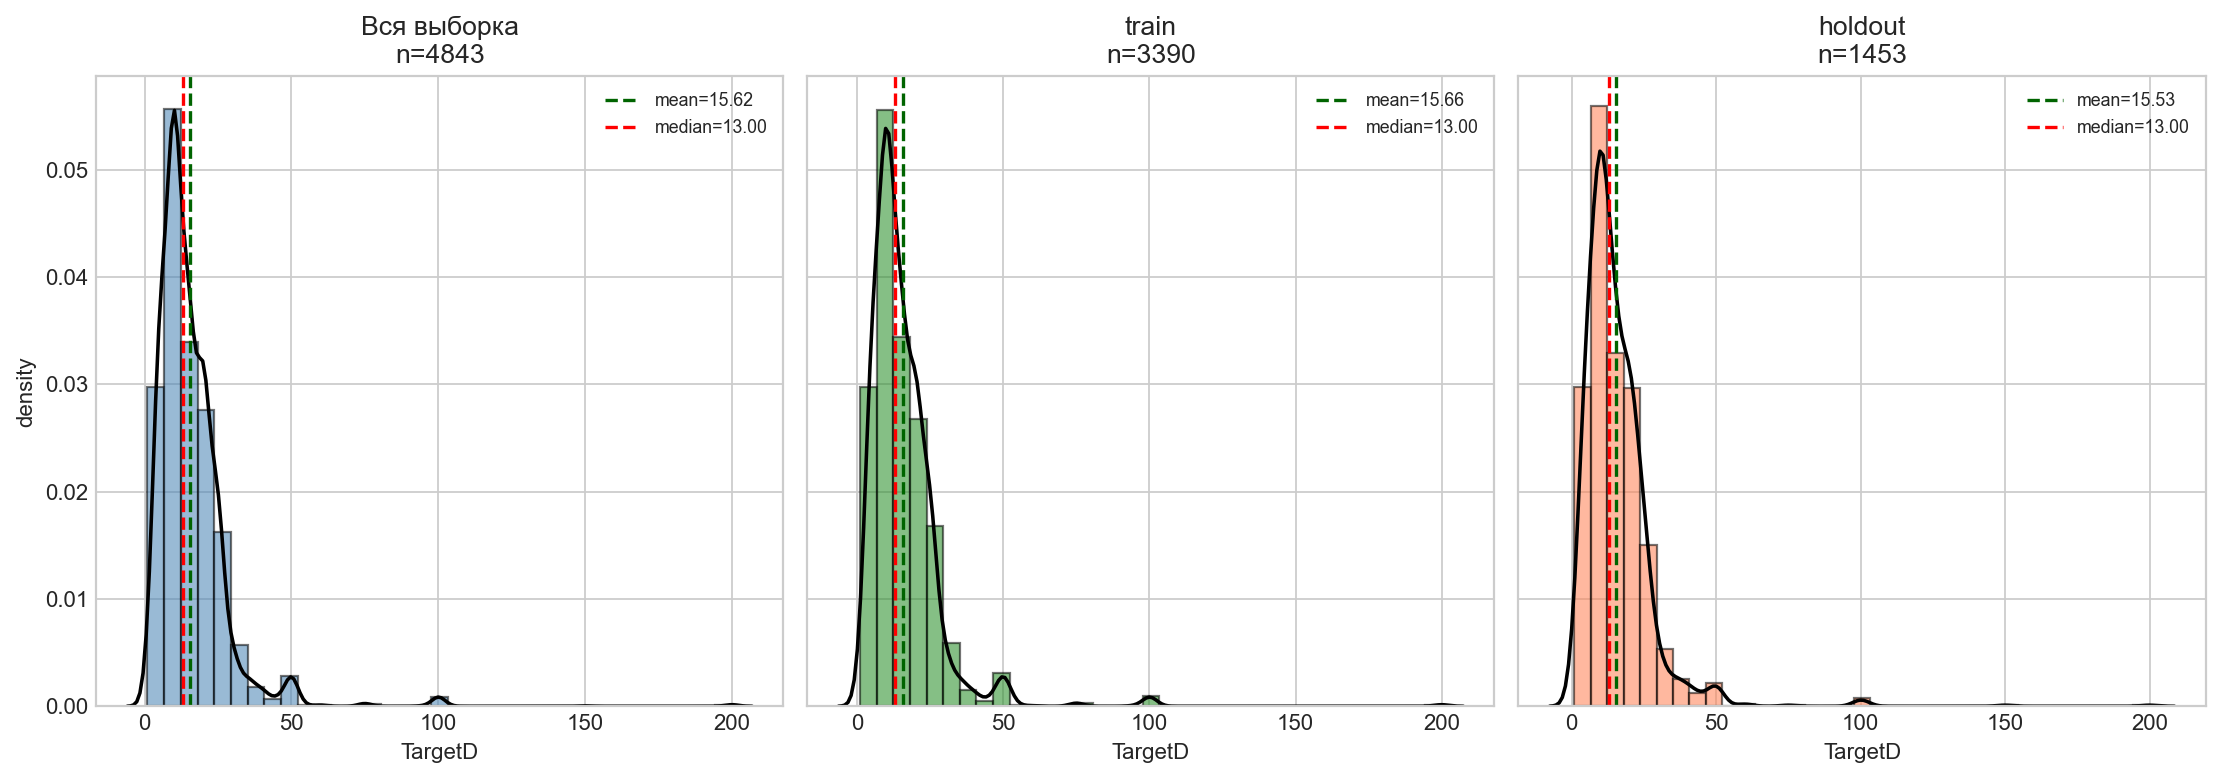

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
for ax, (values, title, color) in zip(
    axes,
    [
        (y_all, "Вся выборка", "steelblue"),
        (train_df["TargetD"], "Обучающая выборка", "forestgreen"),
        (holdout_df["TargetD"], "Проверочная выборка (holdout)", "coral"),
    ],
):
    ax.hist(values, bins=35, density=True, alpha=0.55, color=color, edgecolor="black")
    sns.kdeplot(values, ax=ax, color="black", linewidth=1.6)
    ax.axvline(values.mean(), color="darkgreen", linestyle="--", label=f"mean={values.mean():.2f}")
    ax.axvline(values.median(), color="red", linestyle="--", label=f"median={values.median():.2f}")
    ax.set_title(f"{title}\nn={len(values)}")
    ax.set_xlabel("TargetD")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
save_show("01_target_distribution")

## 3. Предобработка

- `DemCluster` считаем категориальным признаком.
- Для неслучайных пропусков сохраняем бинарные индикаторы.
- Перед KNN-импутацией числовые признаки стандартизируются, так как KNN
  основан на расстояниях.
- Категориальные признаки заполняются модой на train и кодируются one-hot.
- Сильно скошенные неотрицательные числовые признаки преобразуются через
  `log1p`.

3.1 Разделение признаков и индикаторы пропусков

In [33]:
y_train = train_df["TargetD"].to_numpy()
y_holdout = holdout_df["TargetD"].to_numpy()
X_train_raw = train_df.drop(columns=["TargetB", "TargetD", "ID"]).copy()
X_holdout_raw = holdout_df.drop(columns=["TargetB", "TargetD", "ID"]).copy()
categorical_cols = [
    col
    for col in ["StatusCat96NK", "DemGender", "DemHomeOwner", "DemCluster"]
    if col in X_train_raw.columns
]
for col in categorical_cols:
    X_train_raw[col] = X_train_raw[col].astype("object").where(X_train_raw[col].notna(), np.nan)
    X_holdout_raw[col] = X_holdout_raw[col].astype("object").where(X_holdout_raw[col].notna(), np.nan)

numeric_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

In [34]:
cols_with_missing: list[str] = []
for col in numeric_cols + categorical_cols:
    if X_train_raw[col].isna().any() or X_holdout_raw[col].isna().any():
        cols_with_missing.append(col)
        X_train_raw[f"{col}_imputed"] = X_train_raw[col].isna().astype(int)
        X_holdout_raw[f"{col}_imputed"] = X_holdout_raw[col].isna().astype(int)
indicator_cols = [col for col in X_train_raw.columns if col.endswith("_imputed")]


In [35]:
print("числовых признаков:", len(numeric_cols))
print("категориальных признаков:", categorical_cols)
print("признаки с пропусками:", cols_with_missing)

числовых признаков: 21
категориальных признаков: ['StatusCat96NK', 'DemGender', 'DemHomeOwner', 'DemCluster']
признаки с пропусками: ['GiftAvgCard36', 'DemAge', 'DemMedHomeValue', 'DemMedIncome']


3.2 KNN-импутация

Расстояния считаются с учетом нормирования координат. Поэтому перед `KNNImputer` временно стандартизируем признаки, выполняем импутацию в нормированной шкале, затем возвращаем значения в исходную шкалу.

In [36]:
knn_scaler = StandardScaler()
X_train_num_scaled = knn_scaler.fit_transform(X_train_raw[numeric_cols])
X_holdout_num_scaled = knn_scaler.transform(X_holdout_raw[numeric_cols])

imputer = KNNImputer(n_neighbors=5)
X_train_num = pd.DataFrame(
    knn_scaler.inverse_transform(imputer.fit_transform(X_train_num_scaled)),
    columns=numeric_cols,
    index=X_train_raw.index,
)
X_holdout_num = pd.DataFrame(
    knn_scaler.inverse_transform(imputer.transform(X_holdout_num_scaled)),
    columns=numeric_cols,
    index=X_holdout_raw.index,
)

3.3 Логарифмическое преобразование

In [ ]:
skewness = X_train_num.skew(numeric_only=True)
log_transform_cols = [col for col in numeric_cols if X_train_num[col].min() >= 0 and skewness[col] > 1.0]
X_train_num[log_transform_cols] = np.log1p(X_train_num[log_transform_cols])
X_holdout_num[log_transform_cols] = np.log1p(X_holdout_num[log_transform_cols])
print("log1p-преобразованные признаки:", log_transform_cols)

log1p-преобразованные признаки: ['GiftCnt36', 'GiftCntAll', 'GiftCntCard36', 'GiftCntCardAll', 'GiftAvgLast', 'GiftAvg36', 'GiftAvgAll', 'GiftAvgCard36', 'PromCnt12', 'DemMedHomeValue', 'DemMedIncome']


3.4 One-hot кодирование категорий

In [ ]:
X_train_cat_raw = X_train_raw[categorical_cols].copy()
X_holdout_cat_raw = X_holdout_raw[categorical_cols].copy()
for col in categorical_cols:
    mode = X_train_cat_raw[col].mode(dropna=True)
    fill_value = mode.iloc[0] if len(mode) else "missing"
    X_train_cat_raw[col] = X_train_cat_raw[col].fillna(fill_value)
    X_holdout_cat_raw[col] = X_holdout_cat_raw[col].fillna(fill_value)

X_train_cat = pd.get_dummies(X_train_cat_raw.astype("category"), drop_first=True, dtype=float)
X_holdout_cat = pd.get_dummies(X_holdout_cat_raw.astype("category"), drop_first=True, dtype=float)
X_holdout_cat = X_holdout_cat.reindex(columns=X_train_cat.columns, fill_value=0.0)
X_train_ind = X_train_raw[indicator_cols].copy()
X_holdout_ind = X_holdout_raw[indicator_cols].copy()
X_train_prepared = pd.concat([X_train_num, X_train_ind, X_train_cat], axis=1)
X_holdout_prepared = pd.concat([X_holdout_num, X_holdout_ind, X_holdout_cat], axis=1)

## 4. Backward OLS

Стартуем с полной модели. На каждом шаге удаляем переменную с максимальным
`p-value` t-статистики. Лучшая сложность выбирается по 5-fold CV-MSE.

4.1 Стандартизация признаков

In [39]:
model_scaler = StandardScaler()
X_train_scaled = model_scaler.fit_transform(X_train_prepared)
X_holdout_scaled = model_scaler.transform(X_holdout_prepared)
feature_names = X_train_prepared.columns.to_numpy()
print("после предобработки:", X_train_scaled.shape)
print(pd.Series(feature_names, name="feature").head(25).to_string(index=False))

после предобработки: (3390, 86)
              GiftCnt36
             GiftCntAll
          GiftCntCard36
         GiftCntCardAll
            GiftAvgLast
              GiftAvg36
             GiftAvgAll
          GiftAvgCard36
           GiftTimeLast
          GiftTimeFirst
              PromCnt12
              PromCnt36
             PromCntAll
          PromCntCard12
          PromCntCard36
         PromCntCardAll
       StatusCatStarAll
                 DemAge
        DemMedHomeValue
         DemPctVeterans
           DemMedIncome
  GiftAvgCard36_imputed
         DemAge_imputed
DemMedHomeValue_imputed
   DemMedIncome_imputed


4.2 Вспомогательная функция для CV-MSE. 

Средний MSE по 5-блочной CV для OLS на заданном подмножестве признаков.

In [40]:
def compute_cv_mse(X_mat: np.ndarray, y_vec: np.ndarray, feat_indices: list[int]) -> float:
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    mses: list[float] = []
    for tr_idx, val_idx in kf.split(X_mat):
        X_tr = sm.add_constant(X_mat[tr_idx][:, feat_indices], has_constant="add")
        X_val = sm.add_constant(X_mat[val_idx][:, feat_indices], has_constant="add")
        model = sm.OLS(y_vec[tr_idx], X_tr).fit()
        pred = model.predict(X_val)
        mses.append(mean_squared_error(y_vec[val_idx], pred))
    return float(np.mean(mses))


4.3 Backward Stepwise OLS

In [ ]:
remaining = list(range(X_train_scaled.shape[1]))
cv_mses: list[float] = []
complexities: list[int] = []
coef_history = {name: [] for name in feature_names}
best_mse = np.inf
best_complexity: int | None = None
best_features: list[int] | None = None

while len(remaining) > 0:
    X_current = sm.add_constant(X_train_scaled[:, remaining], has_constant="add")
    model = sm.OLS(y_train, X_current).fit()
    mse = compute_cv_mse(X_train_scaled, y_train, remaining)
    cv_mses.append(mse)
    complexities.append(len(remaining))
    params_by_global_idx = {feat_idx: model.params[pos + 1] for pos, feat_idx in enumerate(remaining)}
    for feat_idx, name in enumerate(feature_names):
        coef_history[name].append(params_by_global_idx.get(feat_idx, np.nan))
    if mse < best_mse:
        best_mse = mse
        best_complexity = len(remaining)
        best_features = remaining.copy()
    if len(remaining) == 1:
        break
    worst_local_idx = int(np.argmax(model.pvalues[1:]))
    removed_feat_idx = remaining.pop(worst_local_idx)
    if len(remaining) % 10 == 0 or len(remaining) <= 10:
        print(
            f"Было признаков {len(remaining) + 1:2d}: "
            f"удален {feature_names[removed_feat_idx]!r}, CV-MSE={mse:.3f}"
        )
assert best_features is not None
best_feature_names = feature_names[best_features]
print("\nЛучшая сложность:", best_complexity)
print(f"Лучший CV-MSE Backward OLS: {best_mse:.3f}")
print("Отобранные признаки:")
for name in best_feature_names:
    print("-", name)

Было признаков 81: удален 'PromCntAll', CV-MSE=87.662
Было признаков 71: удален 'PromCntCard36', CV-MSE=87.121
Было признаков 61: удален 'DemCluster_20', CV-MSE=86.716
Было признаков 51: удален 'DemCluster_27', CV-MSE=86.374
Было признаков 41: удален 'DemCluster_31', CV-MSE=86.020
Было признаков 31: удален 'DemCluster_2', CV-MSE=85.956
Было признаков 21: удален 'DemCluster_49', CV-MSE=85.912
Было признаков 11: удален 'DemGender_U', CV-MSE=85.461
Было признаков 10: удален 'DemMedIncome_imputed', CV-MSE=85.391
Было признаков  9: удален 'DemCluster_19', CV-MSE=85.311
Было признаков  8: удален 'DemCluster_42', CV-MSE=85.420
Было признаков  7: удален 'DemHomeOwner_U', CV-MSE=85.529
Было признаков  6: удален 'GiftAvgCard36_imputed', CV-MSE=85.639
Было признаков  5: удален 'GiftCntCard36', CV-MSE=85.825
Было признаков  4: удален 'GiftAvgCard36', CV-MSE=85.919
Было признаков  3: удален 'GiftAvg36', CV-MSE=86.427
Было признаков  2: удален 'GiftAvgAll', CV-MSE=88.135

Лучшая сложность: 9
Лучший 

4.4 Графики: Зависимость CV-MSE от сложности модели и Трасса стандартизованных коэффициентов

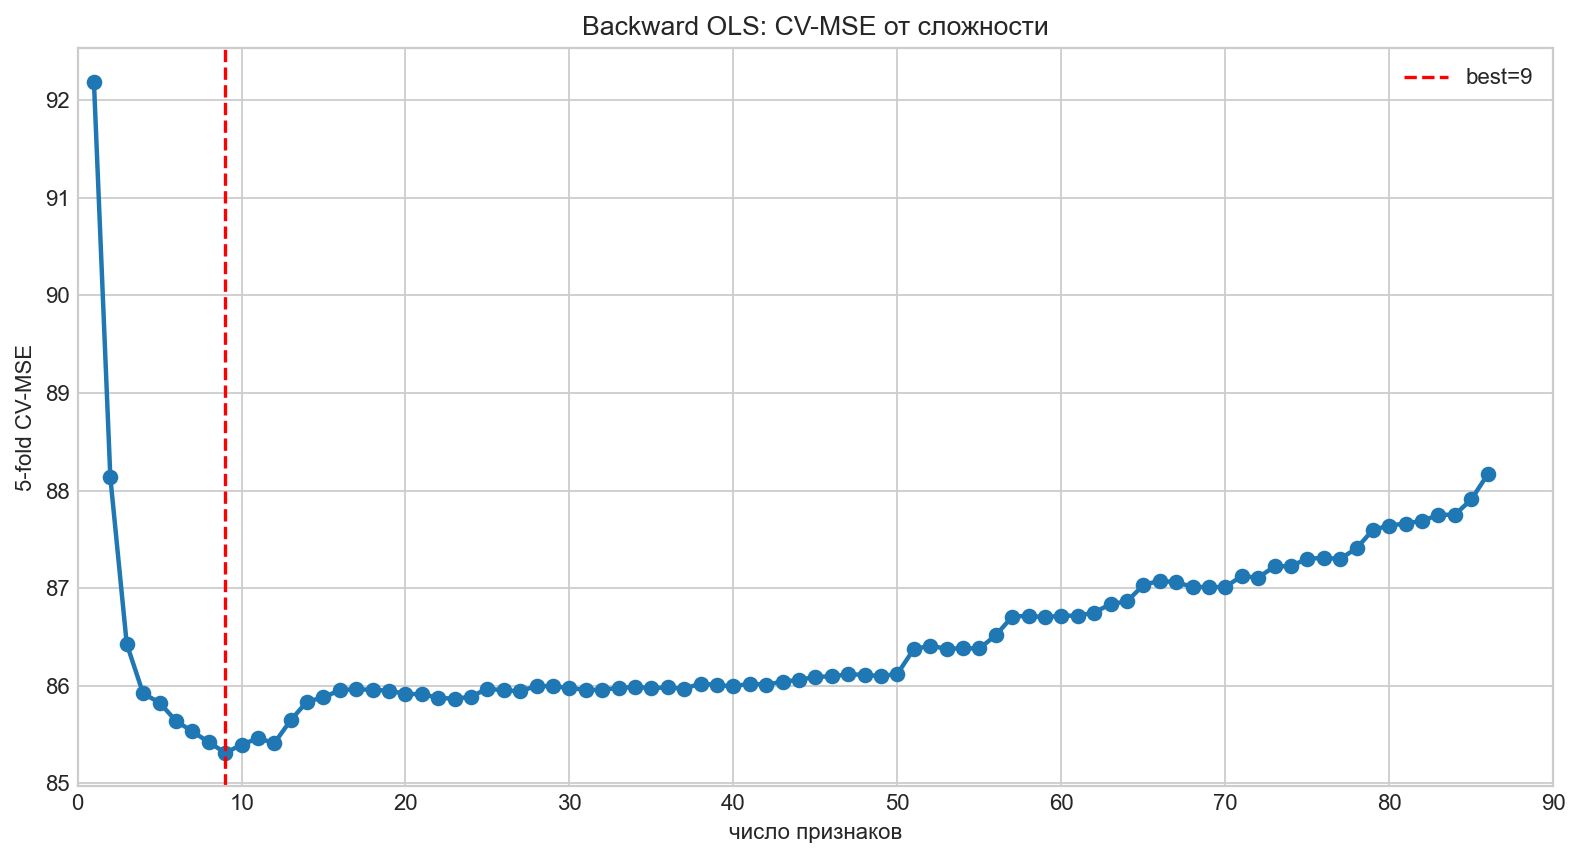

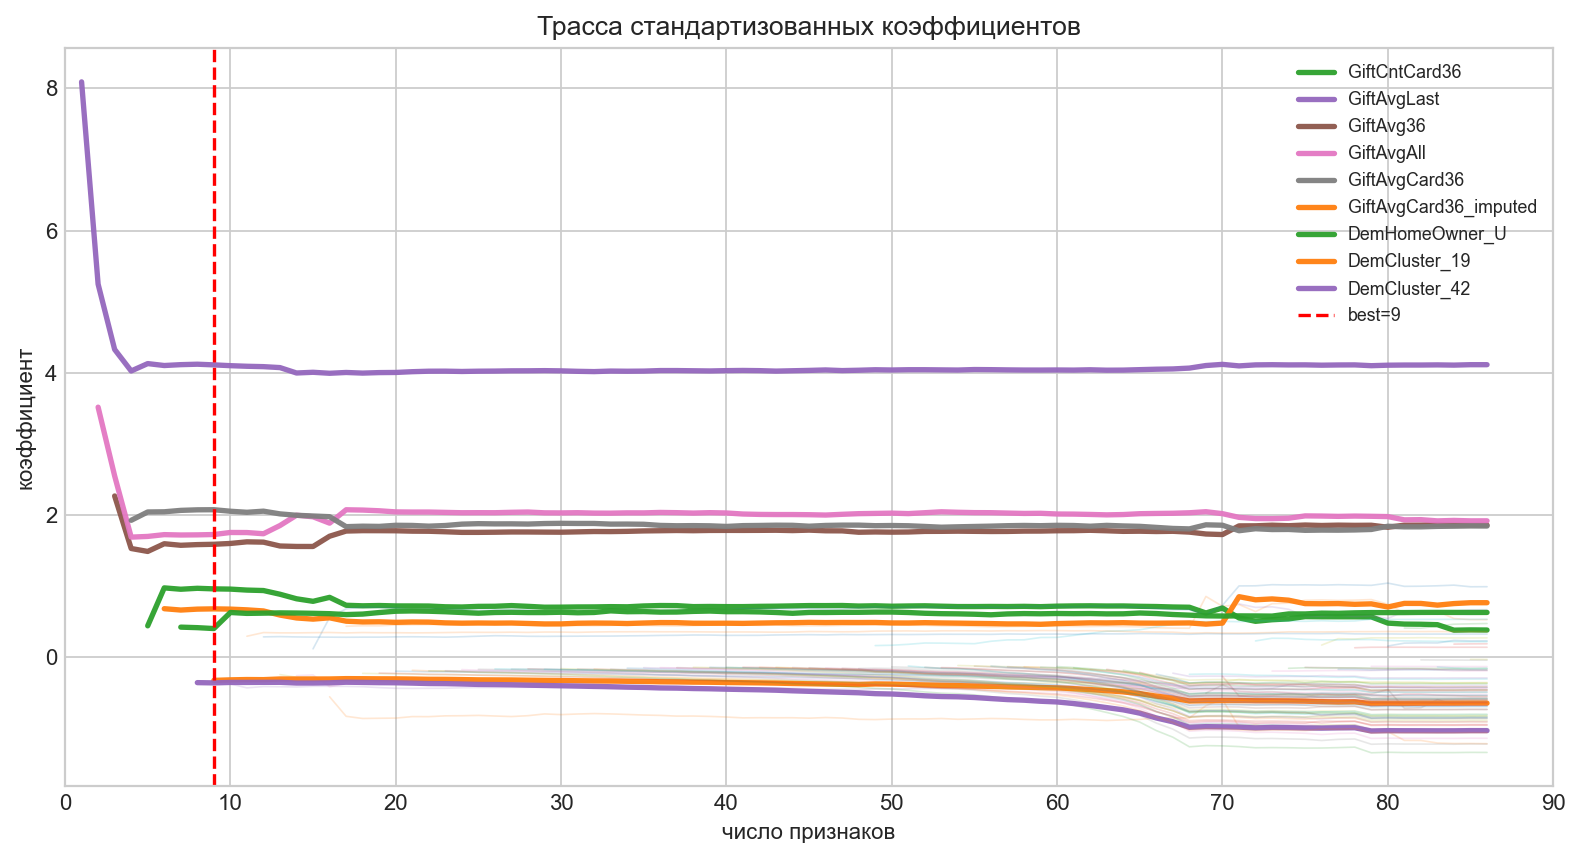

In [ ]:
plot_comp = complexities[::-1]
plot_mse = cv_mses[::-1]
backward_xlim = (0, int(max(plot_comp)) + 1)
backward_xticks = np.arange(0, int(max(plot_comp)) + 10, 10)

plt.figure(figsize=(10, 5.5))
plt.plot(plot_comp, plot_mse, marker="o", linewidth=2)
plt.axvline(best_complexity, color="red", linestyle="--", label=f"best={best_complexity}")
plt.title("Backward OLS")
plt.xlabel("число признаков")
plt.ylabel("5-fold CV-MSE")
plt.xlim(backward_xlim)
plt.xticks(backward_xticks)
plt.legend()
save_show("02_backward_cv_mse")

plt.figure(figsize=(10, 5.5))
for name, coefs in coef_history.items():
    selected = name in set(best_feature_names)
    plt.plot(
        plot_comp,
        coefs[::-1],
        linewidth=2.4 if selected else 0.75,
        alpha=0.95 if selected else 0.18,
        label=name if selected else None,
    )
plt.axvline(best_complexity, color="red", linestyle="--", label=f"best={best_complexity}")
plt.title("Трасса стандартизованных коэффициентов")
plt.xlabel("число признаков")
plt.ylabel("коэффициент")
plt.xlim(backward_xlim)
plt.xticks(backward_xticks)
plt.legend(loc="best", fontsize=8)
save_show("03_backward_coef_trace")

## 5. Линейная модель, bootstrap и OOB
bootstrap используется для оценки неопределенности параметров, а `out-of-bag` наблюдения позволяют оценивать ошибку без пересечения с bootstrap-выборкой. Здесь строим 100 bootstrap-выборок размера 25% от обучающей выборки.

5.1 Обучение на всех отобранных признаках

In [ ]:
X_train_best = X_train_scaled[:, best_features]
X_holdout_best = X_holdout_scaled[:, best_features]
linear_model = sm.OLS(y_train, sm.add_constant(X_train_best, has_constant="add")).fit()
linear_train_pred = linear_model.predict(sm.add_constant(X_train_best, has_constant="add"))
linear_holdout_pred = linear_model.predict(sm.add_constant(X_holdout_best, has_constant="add"))
linear_train_mse = mean_squared_error(y_train, linear_train_pred)
linear_holdout_mse = mean_squared_error(y_holdout, linear_holdout_pred)

print(f"Linear train MSE:   {linear_train_mse:.3f}")
print(f"Linear CV-MSE:      {best_mse:.3f}")
print(f"Linear holdout MSE: {linear_holdout_mse:.3f}")
print(linear_model.summary())

Linear train MSE:   84.410
Linear CV-MSE:      85.311
Linear holdout MSE: 79.801
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.462
Method:                 Least Squares   F-statistic:                     324.6
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        16:01:42   Log-Likelihood:                -12329.
No. Observations:                3390   AIC:                         2.468e+04
Df Residuals:                    3380   BIC:                         2.474e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

5.2 100 bootstrap-выборок размера 25% от обучающей выборки.

In [ ]:
rng = np.random.default_rng(RANDOM_STATE)
n_train = len(y_train)
bootstrap_size = int(0.25 * n_train)
all_train_idx = np.arange(n_train)
linear_intercepts: list[float] = []
linear_oob_mses: list[float] = []
for _ in range(100):
    boot_idx = rng.choice(all_train_idx, size=bootstrap_size, replace=True)
    oob_mask = np.ones(n_train, dtype=bool)
    oob_mask[np.unique(boot_idx)] = False
    boot_model = sm.OLS(
        y_train[boot_idx],
        sm.add_constant(X_train_best[boot_idx], has_constant="add"),
    ).fit()
    oob_pred = boot_model.predict(sm.add_constant(X_train_best[oob_mask], has_constant="add"))
    linear_intercepts.append(float(boot_model.params[0]))
    linear_oob_mses.append(mean_squared_error(y_train[oob_mask], oob_pred))
linear_intercepts_arr = np.array(linear_intercepts)
linear_oob_mses_arr = np.array(linear_oob_mses)
linear_intercept_mean = float(linear_intercepts_arr.mean())
linear_intercept_ci = np.percentile(linear_intercepts_arr, [2.5, 97.5])
linear_oob_mse_mean = float(linear_oob_mses_arr.mean())
linear_oob_mse_ci = np.percentile(linear_oob_mses_arr, [2.5, 97.5])

print(f"Bootstrap size: {bootstrap_size}")
print(f"Intercept mean: {linear_intercept_mean:.3f}")
print(f"Intercept 95% CI: [{linear_intercept_ci[0]:.3f}; {linear_intercept_ci[1]:.3f}]")
print(f"Linear OOB MSE mean: {linear_oob_mse_mean:.3f}")
print(f"Linear OOB MSE 95% CI: [{linear_oob_mse_ci[0]:.3f}; {linear_oob_mse_ci[1]:.3f}]")

Bootstrap size: 847
Intercept mean: 15.650
Intercept 95% CI: [15.126; 16.388]
Linear OOB MSE mean: 88.306
Linear OOB MSE 95% CI: [76.270; 97.649]


5.3 Визуализация результатов бутстрэпа

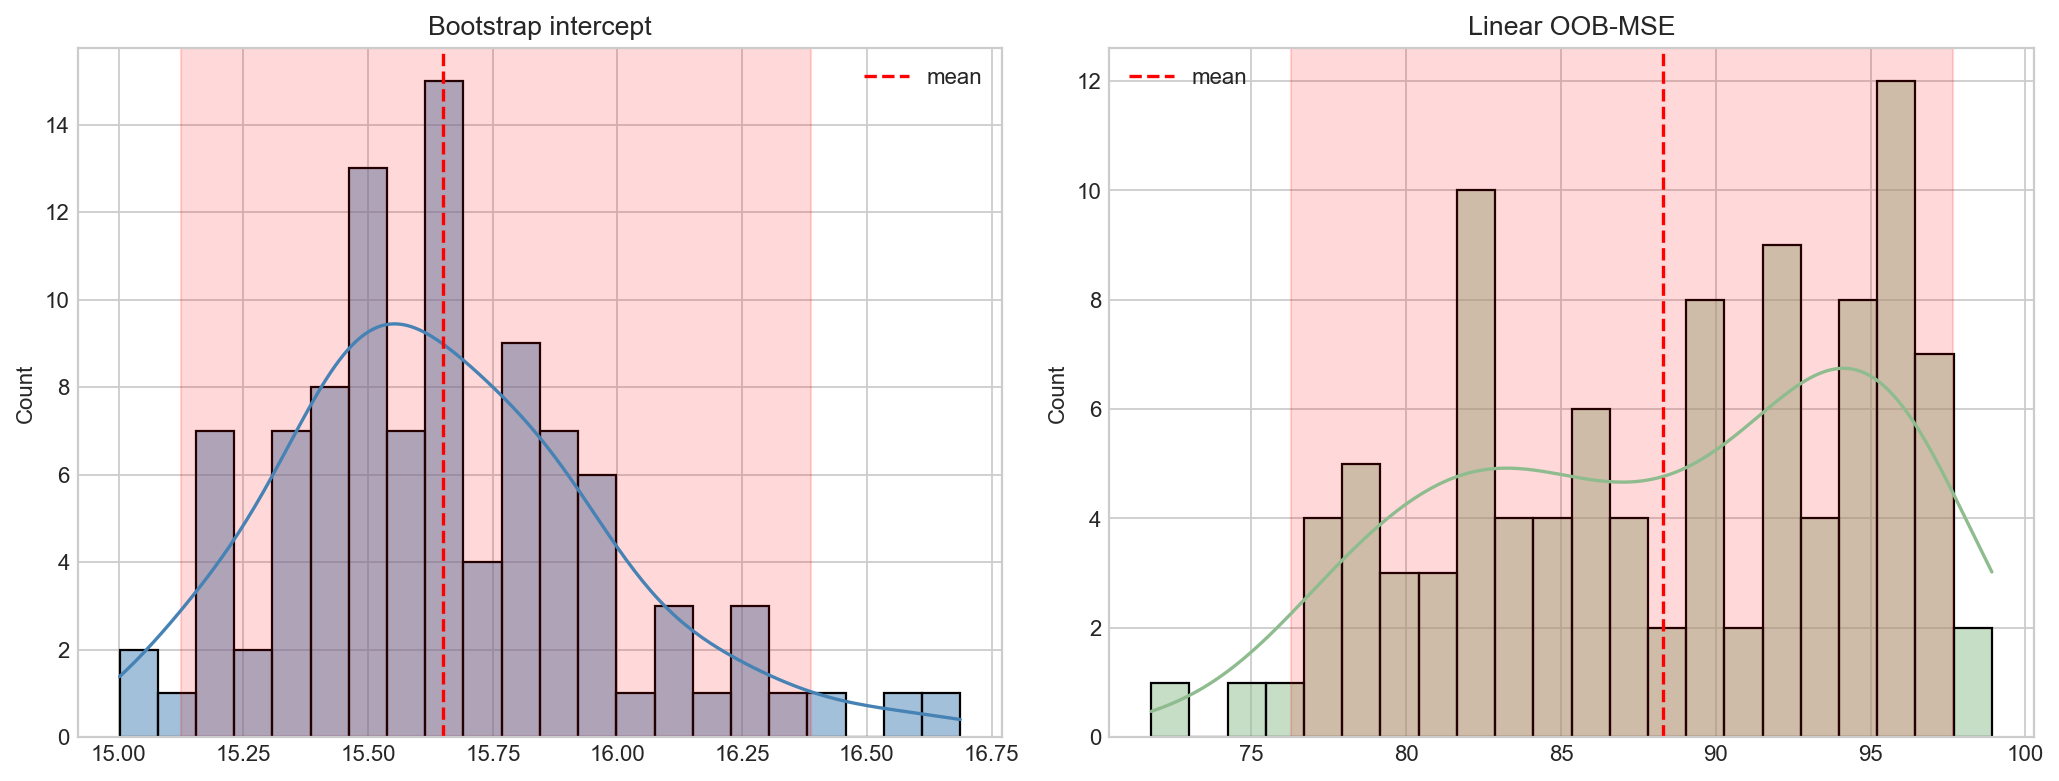

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(linear_intercepts_arr, bins=22, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(linear_intercept_mean, color="red", linestyle="--", label="mean")
axes[0].axvspan(linear_intercept_ci[0], linear_intercept_ci[1], color="red", alpha=0.15)
axes[0].set_title("Bootstrap intercept")
axes[0].legend()

sns.histplot(linear_oob_mses_arr, bins=22, kde=True, ax=axes[1], color="darkseagreen")
axes[1].axvline(linear_oob_mse_mean, color="red", linestyle="--", label="mean")
axes[1].axvspan(linear_oob_mse_ci[0], linear_oob_mse_ci[1], color="red", alpha=0.15)
axes[1].set_title("Linear OOB-MSE")
axes[1].legend()
save_show("04_linear_bootstrap")

* OOB‑MSE (88.36) очень близка к CV‑MSE (85.31). Это подтверждает, что обе оценки дают сопоставимую характеристику обобщающей способности.

* OOB‑MSE имеет довольно широкий доверительный интервал (от 76 до 97) – что говорит о заметной вариативности ошибки в зависимости от того, какие наблюдения попадают в бутстрэп-выборку.

## 6. MLP (relu) + HalvingGridSearchCV

MLP рассматривается как сеть прямого распространения для моделирования нелинейных зависимостей. Используем ReLU-активацию. Число нейронов и регуляризацию `alpha` подбираем по решетке через `HalvingGridSearchCV`.

In [61]:
mlp = MLPRegressor(
    activation="relu",
    solver="adam",
    learning_rate_init=0.01,
    random_state=RANDOM_STATE,
    early_stopping=False 
)

param_grid = {
    "hidden_layer_sizes": [(2,), (4,), (8,), (16,), (32,)],
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]
}

mlp_search = HalvingGridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    factor=2,
    resource="max_iter",
    min_resources=100,
    max_resources=800,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=0
)
mlp_search.fit(X_train_best, y_train)
mlp_best_model = mlp_search.best_estimator_
mlp_full_cv_mse = -float(mlp_search.best_score_)
mlp_train_pred = mlp_best_model.predict(X_train_best)
mlp_holdout_pred = mlp_best_model.predict(X_holdout_best)
mlp_train_mse = mean_squared_error(y_train, mlp_train_pred)
mlp_holdout_mse = mean_squared_error(y_holdout, mlp_holdout_pred)

print("Лучшие параметры MLP:", mlp_search.best_params_)
print(f"MLP train MSE:        {mlp_train_mse:.3f}")
print(f"MLP CV-MSE:           {mlp_full_cv_mse:.3f}")
print(f"MLP holdout MSE:      {mlp_holdout_mse:.3f}")
print(f"|train - holdout|:    {abs(mlp_train_mse - mlp_holdout_mse):.3f}")


c:\Users\Admin\Documents\Университет\4 семестр\МО\LW\2\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Лучшие параметры MLP: {'alpha': 0.1, 'hidden_layer_sizes': (8,), 'max_iter': 800}
MLP train MSE:        63.704
MLP CV-MSE:           70.503
MLP holdout MSE:      67.590
|train - holdout|:    3.886


График – «решетка» перебора метапараметров

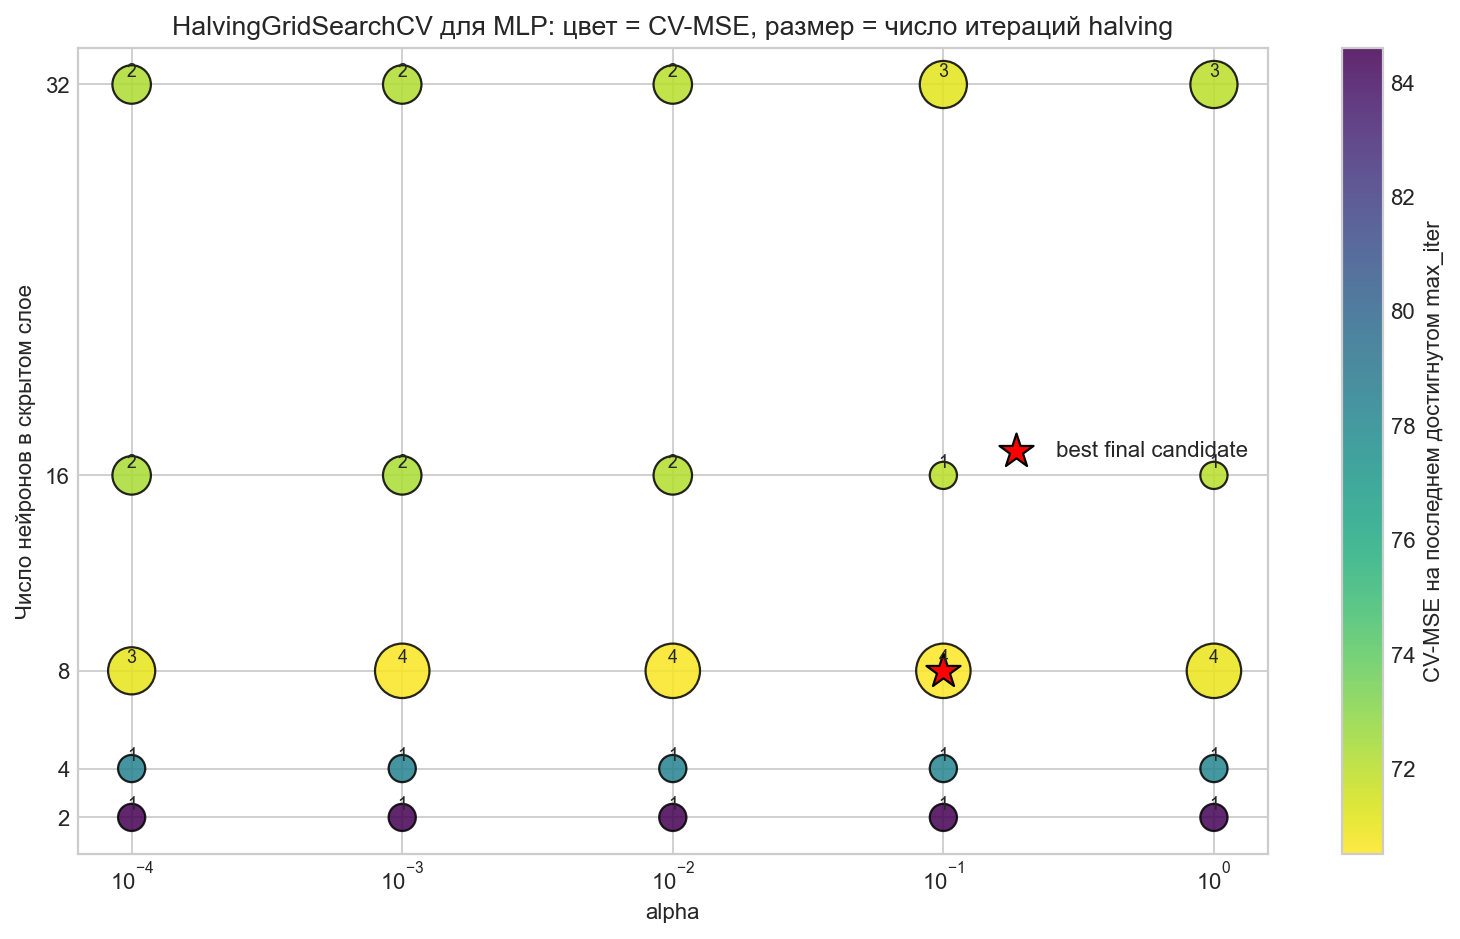


Оценки halving-решетки:
hidden_layer_sizes  alpha  halving_repeats  last_iter  max_iter_used  last_mse
              (8,)  0.100                4          3            800    70.503
              (8,)  0.001                4          3            800    70.632
              (8,)  0.010                4          3            800    70.651
              (8,)  1.000                4          3            800    70.907
              (8,)  0.000                3          2            400    71.013
             (32,)  0.100                3          2            400    71.135
             (32,)  1.000                3          2            400    71.979
             (32,)  0.010                2          1            200    72.008
             (16,)  0.010                2          1            200    72.143
             (32,)  0.001                2          1            200    72.182
             (32,)  0.000                2          1            200    72.252
             (16,)  0.001  

In [59]:
cv_results = pd.DataFrame(mlp_search.cv_results_).copy()
cv_results["mse"] = -cv_results["mean_test_score"]
cv_results["hidden_layer_sizes"] = cv_results["param_hidden_layer_sizes"].astype(str)
cv_results["neurons"] = cv_results["param_hidden_layer_sizes"].apply(lambda x: x[0])
cv_results["alpha"] = cv_results["param_alpha"].astype(float)
cv_results["max_iter_used"] = cv_results["param_max_iter"].astype(int)
keys = ["hidden_layer_sizes", "neurons", "alpha"]
repeat_counts = (
    cv_results.groupby(keys)
    .size()
    .rename("halving_repeats")
    .reset_index()
)
last_scores = (
    cv_results.sort_values(keys + ["iter"])
    .groupby(keys, as_index=False)
    .tail(1)[keys + ["mse", "max_iter_used", "iter"]]
    .rename(columns={"mse": "last_mse", "iter": "last_iter"})
)
grid_plot = last_scores.merge(repeat_counts, on=keys)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    grid_plot["alpha"],
    grid_plot["neurons"],
    c=grid_plot["last_mse"],
    s=grid_plot["halving_repeats"] * 150,
    cmap="viridis_r",
    edgecolor="black",
    alpha=0.85,
)
plt.scatter(
    mlp_search.best_params_["alpha"],
    mlp_search.best_params_["hidden_layer_sizes"][0],
    marker="*",
    s=260,
    color="red",
    edgecolor="black",
    label="best final candidate",
)
for _, row in grid_plot.iterrows():
    plt.text(
        row["alpha"],
        row["neurons"] + 0.17,
        int(row["halving_repeats"]),
        ha="center",
        va="bottom",
        fontsize=8,
)
plt.xscale("log")
plt.yticks(sorted(grid_plot["neurons"].unique()))
plt.xlabel("alpha")
plt.ylabel("Число нейронов в скрытом слое")
plt.title("HalvingGridSearchCV для MLP: цвет = CV-MSE, размер = число итераций halving")
colorbar = plt.colorbar(scatter)
colorbar.set_label("CV-MSE на последнем достигнутом max_iter")
plt.legend()
save_show("05_mlp_halving_grid")

print("\nОценки halving-решетки:")
print(
    grid_plot[["hidden_layer_sizes", "alpha", "halving_repeats", "last_iter", "max_iter_used", "last_mse"]]
    .sort_values(["halving_repeats", "last_mse"], ascending=[False, True])
    .head(12)
    .round(3)
    .to_string(index=False)
)

## 7. Сравнение линейной и нелинейной моделей

CV оценивает качество при выборе модели, OOB дает bootstrap-оценку ошибки без пересечения с обучающей bootstrap-выборкой, а holdout остается внешней проверкой.

7.1 OOB для MLP 

In [ ]:
mlp_oob_mses: list[float] = []
for _ in range(MLP_OOB_REPEATS):
    boot_idx = rng.choice(all_train_idx, size=bootstrap_size, replace=True)
    oob_mask = np.ones(n_train, dtype=bool)
    oob_mask[np.unique(boot_idx)] = False
    boot_mlp = clone(mlp_best_model)
    boot_mlp.fit(X_train_best[boot_idx], y_train[boot_idx])
    oob_pred = boot_mlp.predict(X_train_best[oob_mask])
    mlp_oob_mses.append(mean_squared_error(y_train[oob_mask], oob_pred))

mlp_oob_mses_arr = np.array(mlp_oob_mses)
mlp_oob_mse_mean = float(mlp_oob_mses_arr.mean())
mlp_oob_mse_ci = np.percentile(mlp_oob_mses_arr, [2.5, 97.5])

7.2 Итоговое сравнение

In [51]:
comparison = pd.DataFrame(
    {
        "model": ["Backward OLS", "MLP relu"],
        "train MSE": [linear_train_mse, mlp_train_mse],
        "CV MSE": [best_mse, mlp_full_cv_mse],
        "OOB MSE mean": [linear_oob_mse_mean, mlp_oob_mse_mean],
        "OOB MSE 2.5%": [linear_oob_mse_ci[0], mlp_oob_mse_ci[0]],
        "OOB MSE 97.5%": [linear_oob_mse_ci[1], mlp_oob_mse_ci[1]],
        "holdout MSE": [linear_holdout_mse, mlp_holdout_mse],
        "|train-holdout|": [
            abs(linear_train_mse - linear_holdout_mse),
            abs(mlp_train_mse - mlp_holdout_mse),
        ],
    }
)

print(comparison.round(3).to_string(index=False))
print("\nЛучшая модель по CV:", comparison.loc[comparison["CV MSE"].idxmin(), "model"])
print("Лучшая модель по holdout:", comparison.loc[comparison["holdout MSE"].idxmin(), "model"])

       model  train MSE  CV MSE  OOB MSE mean  OOB MSE 2.5%  OOB MSE 97.5%  holdout MSE  |train-holdout|
Backward OLS     84.410  85.311        88.306        76.270         97.649       79.801            4.608
    MLP relu     63.704  70.503        77.953        65.594         93.175       67.590            3.886

Лучшая модель по CV: MLP relu
Лучшая модель по holdout: MLP relu


**Вывод:** Для прогнозирования суммы пожертвования целесообразно использовать нелинейную модель – MLP с одним скрытым слоем из 8 нейронов и регуляризацией alpha=0.1. Она обеспечивает существенное снижение ошибки предсказания (на 15–24%) по сравнению с линейной регрессией, отобранной методом Backward OLS. Несмотря на более высокую вычислительную сложность, MLP лучше отражает структуру данных и является предпочтительным выбором для практического применения.